# 📊 Exploratory Data Analysis (EDA) — E-Commerce Fraud Dataset

## Objective
The goal of this notebook is to rigorously analyze the preprocessed e-commerce transaction dataset, surface hidden patterns correlated with fraudulent behavior, and establish a data-driven justification for subsequent feature engineering and machine learning model design.

### Key Focus Areas:
1. **Target Variable Analysis:** Quantifying the extent of class imbalance.
2. **Geographical Risks:** Identifying high-volume and high-risk fraud countries.
3. **Behavioral & Device Patterns:** Evaluating fraud distributions across browser choices and user behaviors.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Using the exact absolute path to the actual file discovered in your project environment
DATA_PATH = r"C:\Users\hiwot\Desktop\fraud-detection\data\processed\cleaned_fraud_data.csv"

print(f"Loading processed dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Display structural baseline
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head())

Loading processed dataset from: C:\Users\hiwot\Desktop\fraud-detection\data\processed\cleaned_fraud_data.csv



Dataset Shape: 151112 rows, 18 columns


   user_id          signup_time        purchase_time  purchase_value  \
0    62421  2015-02-16 00:17:05  2015-03-08 10:00:39              46   
1   173212  2015-03-08 04:03:22  2015-03-20 17:23:45              33   
2   242286  2015-05-17 16:45:54  2015-05-26 08:54:34              33   
3   370003  2015-03-03 19:58:39  2015-05-28 21:09:13              33   
4   119824  2015-03-20 00:31:27  2015-04-05 07:31:46              55   

       device_id  source  browser sex  age     ip_address  class  ip_int  \
0  ZCLZTAJPCRAQX  Direct   Safari   M   36   52093.496895      0   52093   
1  YFGYOALADBHLT     Ads       IE   F   30   93447.138961      0   93447   
2  QZNVQTUITFTHH  Direct  FireFox   F   32  105818.501505      0  105818   
3  PIBUQMBIELMMG     Ads       IE   M   40  117566.664867      0  117566   
4  WFIIFCPIOGMHT     Ads   Safari   M   38  131423.789042      0  131423   

   lower_bound_ip_address  upper_bound_ip_address country  time_since_signup  \
0                     NaN     

## 1. Class Imbalance Analysis
Understanding the baseline distribution of the target variable (`class`) is crucial. Severe class imbalances dictate whether standard accuracy metrics will fail and highlight the eventual need for stratified splitting, sampling adjustments (like SMOTE), or balance-sensitive loss functions.

C:\Users\hiwot\AppData\Local\Temp\ipykernel_6792\3899981701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=df, palette='viridis')


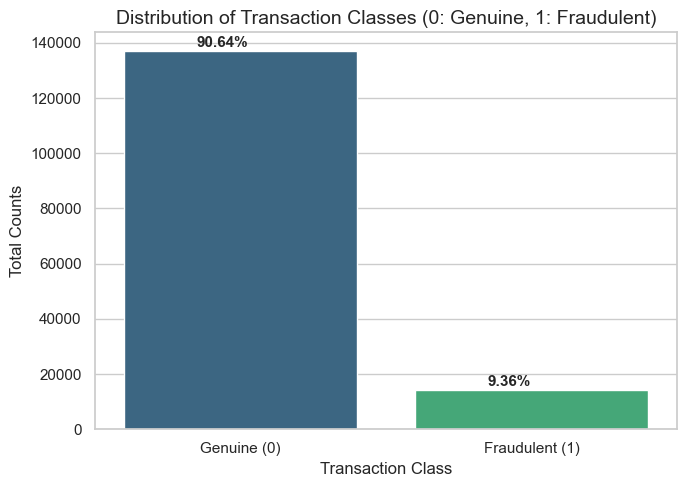

--- Class Proportions ---
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='class', data=df, palette='viridis')

# Calculate percentages to display on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.15
    y_coord = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x_coord, y_coord), weight='bold')

plt.title("Distribution of Transaction Classes (0: Genuine, 1: Fraudulent)")
plt.xlabel("Transaction Class")
plt.ylabel("Total Counts")
plt.xticks([0, 1], ['Genuine (0)', 'Fraudulent (1)'])
plt.tight_layout()
plt.show()

# Print text backup summary
print("--- Class Proportions ---")
print(df['class'].value_counts(normalize=True) * 100)

## 2. Geographical Fraud Profiling
Next, we evaluate where the fraudulent activities are originating. We want to see both the raw transaction counts per country and the actual *fraud rate* (proportions) to decouple high transaction volume from high risk.

C:\Users\hiwot\AppData\Local\Temp\ipykernel_6792\3755429829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_countries.values, y=top_fraud_countries.index, ax=axes[0], palette='magma')


C:\Users\hiwot\AppData\Local\Temp\ipykernel_6792\3755429829.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rates.values, y=fraud_rates.index, ax=axes[1], palette='flare')


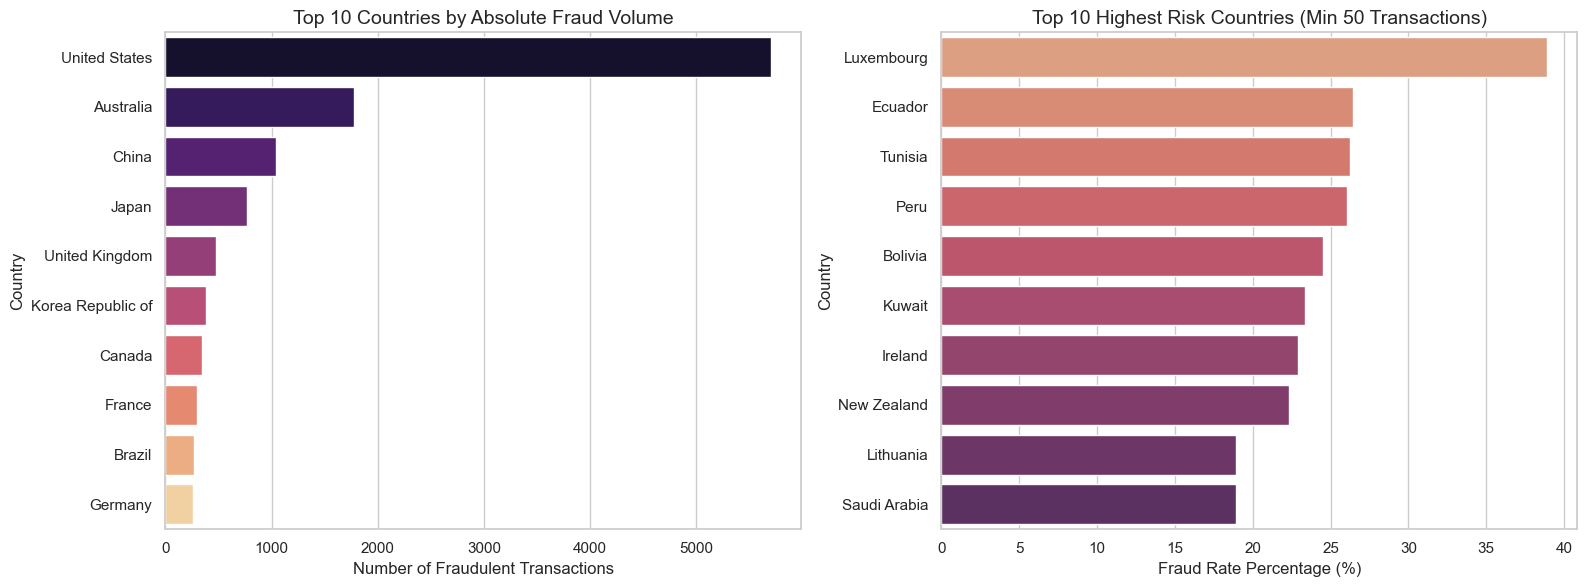

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Absolute Fraud Counts by Top 10 Countries
fraud_df = df[df['class'] == 1]
top_fraud_countries = fraud_df['country'].value_counts().head(10)

sns.barplot(x=top_fraud_countries.values, y=top_fraud_countries.index, ax=axes[0], palette='magma')
axes[0].set_title("Top 10 Countries by Absolute Fraud Volume")
axes[0].set_xlabel("Number of Fraudulent Transactions")
axes[0].set_ylabel("Country")

# Subplot 2: Relative Fraud Rates by Country (Min 50 total transactions to avoid outliers)
country_counts = df['country'].value_counts()
valid_countries = country_counts[country_counts >= 50].index

fraud_rates = (df[df['country'].isin(valid_countries)]
               .groupby('country')['class']
               .mean()
               .sort_values(ascending=False)
               .head(10) * 100)

sns.barplot(x=fraud_rates.values, y=fraud_rates.index, ax=axes[1], palette='flare')
axes[1].set_title("Top 10 Highest Risk Countries (Min 50 Transactions)")
axes[1].set_xlabel("Fraud Rate Percentage (%)")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()

## 3. Digital Footprint Analysis: Browsers
Are bad actors heavily leveraging specific browsers to initiate automated scripts or take advantage of specific session characteristics? Let's break down total transaction presence versus explicit fraud likelihood per browser category.

C:\Users\hiwot\AppData\Local\Temp\ipykernel_6792\3736826837.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='browser', y='mean', data=browser_analysis, palette='coolwarm')


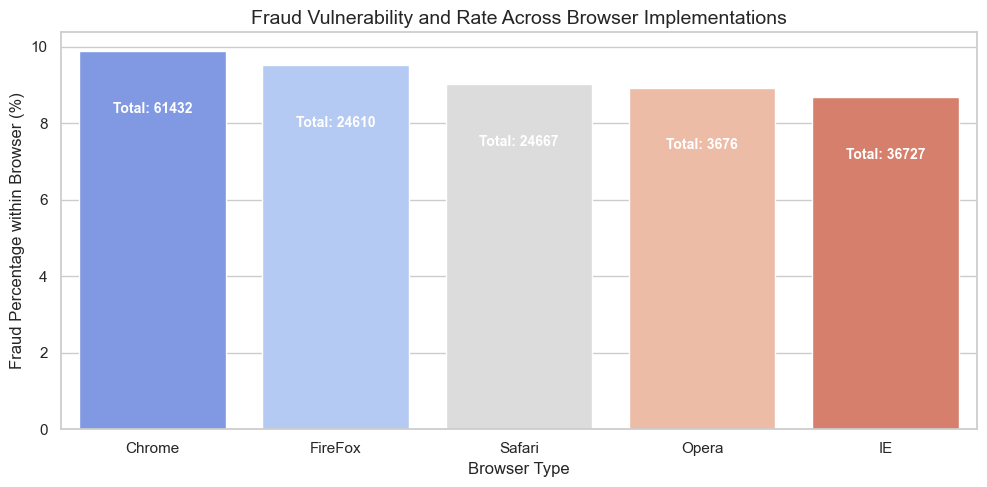

In [4]:
plt.figure(figsize=(10, 5))

# Calculate explicit fraud rates grouped by browser type
browser_analysis = df.groupby('browser')['class'].agg(['count', 'mean']).reset_index()
browser_analysis['mean'] = browser_analysis['mean'] * 100
browser_analysis = browser_analysis.sort_values(by='mean', ascending=False)

ax = sns.barplot(x='browser', y='mean', data=browser_analysis, palette='coolwarm')

# Annotate counts inside/above the bars for context
for i, p in enumerate(ax.patches):
    count_val = browser_analysis.iloc[i]['count']
    ax.annotate(f"Total: {count_val}", 
                (p.get_x() + p.get_width() / 2., p.get_height() - 1.5),
                ha='center', va='center', color='white', weight='bold', fontsize=10)

plt.title("Fraud Vulnerability and Rate Across Browser Implementations")
plt.xlabel("Browser Type")
plt.ylabel("Fraud Percentage within Browser (%)")
plt.tight_layout()
plt.show()